<a href="https://colab.research.google.com/github/yeswanthreddy312/Learnable_DT_for_LWM/blob/main/Learnable_DT_Expts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Google collab persist
#  1. Mount drive dir to persist datasets,model  etc..,
from google.collab import drive
drive.mount('/content/drive/Learnable_DT_collabspace')

# 2. Environment build
!pip install -r requirements.txt

In [ ]:
import sionna.rt as rt
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def initialize_scene(scene_input, tx_pos=[0, 0, 30], rx_pos=[100, 100, 1.5], is_builtin=True):
    """
    Initializes a Sionna RT scene from either a built-in identifier,
    a local file path (.obj/.xml), or an OSM-derived source.
    """
    if is_builtin:
        scene = rt.load_scene(scene_input)
    else:
        scene = rt.load_scene(scene_input)

    tx = rt.Transmitter(name="tx", position=tx_pos)
    scene.add(tx)

    rx = rt.Receiver(name="rx", position=rx_pos)
    scene.add(rx)

    print("Successfully loaded scene.")
    print(f"Added TX at {tx_pos} and RX at {rx_pos}")

    return scene

def contextual_material_pipeline(scene, image_data=None, segmentation_map=None):
    """
    Placeholder for an advanced pipeline that uses 3D context or
    Computer Vision results to rename scene objects.
    """
    print("Starting contextual analysis...")
    pass

def rename_scene_objects(scene, mapping_dict):
    """
    Renames objects in the scene based on a provided dictionary.
    """
    renamed_count = 0
    for name, obj in list(scene.objects.items()):
        for old_sub, new_name in mapping_dict.items():
            if old_sub in name:
                obj.name = new_name
                renamed_count += 1
                break
    print(f"Renamed {renamed_count} objects based on mapping.")

def assign_materials_by_name(scene):
    """
    Iterates through all objects in the scene and assigns materials.
    Tracks default assignments for later refinement and returns the material dict and default names.
    """
    materials = [
        rt.RadioMaterial("concrete", relative_permittivity=7.0, conductivity=0.015),
        rt.RadioMaterial("glass", relative_permittivity=6.273, conductivity=0.001),
        rt.RadioMaterial("metal", relative_permittivity=1.0, conductivity=1e7)
    ]

    for mat in materials:
        try:
            scene.add(mat)
        except ValueError:
            pass

    default_assignments = []
    for name, obj in scene.objects.items():
        if "building" in name.lower():
            obj.radio_material = "concrete"
        elif "window" in name.lower() or "glass" in name.lower():
            obj.radio_material = "glass"
        elif "pole" in name.lower() or "metal" in name.lower():
            obj.radio_material = "metal"
        else:
            obj.radio_material = "concrete"
            default_assignments.append(name)

    print(f"Materials assigned to {len(scene.objects)} objects.")
    print(f"Default assignment ('concrete') applied to {len(default_assignments)} objects.")
    if default_assignments:
        print(f"Examples of default assignments: {default_assignments[:5]}")

    # Return materials and the list of names that weren't matched
    return scene.radio_materials, default_assignments

def material_feedback_loop(default_names):
    """
    Placeholder for a feedback loop that identifies objects with generic names
    and suggests materials based on external metadata or vision models.
    """
    if not default_names:
        print("No default assignments found. All objects matched keywords.")
        return

    print(f"--- Feedback Loop Triggered ---")
    print(f"Found {len(default_names)} objects requiring attention (e.g., {default_names[:3]}).")

    # In a real scenario, this is where we would:
    # 1. Query an LLM or Vision Model: 'What is object Heilig_Geist-itu_marble?'
    # 2. Get Suggestion: 'It is a stone/concrete building.'
    # 3. Update the mapping_dict and re-run the pipeline.

    print("Status: Awaiting manual or automated material suggestions for these objects.")

In [3]:
# --- CONSOLIDATED DIGITAL TWIN PIPELINE ---

def initialize_radio_digital_twin(scene_source=rt.scene.munich, is_builtin=True):
    """
    One-stop initialization: Loads scene, adds TX/RX, and maps materials.
    Returns the scene object, the current materials, and the list of unmatched objects.
    """
    print("--- Step 1: Initializing Scene Geometry ---")
    scene = initialize_scene(scene_source, is_builtin=is_builtin)

    print("\n--- Step 2: Assigning Materials & Identifying Gaps ---")
    # Returns active materials and objects that didn't match keywords (the gaps)
    current_materials, unmatched_objects = assign_materials_by_name(scene)

    print("\nDigital Twin Setup Complete.")
    return scene, current_materials, unmatched_objects

# --- Execution Flow ---

# 1. Run the main pipeline
scene, mats, gaps = initialize_radio_digital_twin(scene_source=rt.scene.munich)

# 2. Trigger the feedback loop for the identified gaps (e.g., 'no-name' objects)
print("\n--- Step 3: Triggering Feedback Loop for Refinement ---")
material_feedback_loop(gaps)

--- Step 1: Initializing Scene Geometry ---
Successfully loaded scene.
Added TX at [0, 0, 30] and RX at [100, 100, 1.5]

--- Step 2: Assigning Materials & Identifying Gaps ---
Materials assigned to 11 objects.
Default assignment ('concrete') applied to 8 objects.
Examples of default assignments: ['Heilig_Geist-itu_marble', 'Frauenkirche-itu_marble', 'St__Peter-itu_marble', 'ground', 'no-name-1']

Digital Twin Setup Complete.

--- Step 3: Triggering Feedback Loop for Refinement ---
--- Feedback Loop Triggered ---
Found 8 objects requiring attention (e.g., ['Heilig_Geist-itu_marble', 'Frauenkirche-itu_marble', 'St__Peter-itu_marble']).
Status: Awaiting manual or automated material suggestions for these objects.


--- Step 4: Computing Radio Map ---
Radio Map computation complete.


<Figure size 1000x800 with 0 Axes>

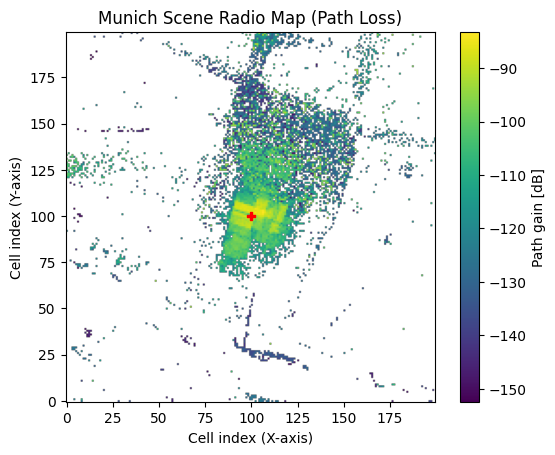

In [4]:
def compute_radio_map(scene):
    """
    Computes a radio map using the RadioMapSolver as seen in the Radio-Maps notebook.
    """
    print("--- Step 4: Computing Radio Map ---")

    # 1. Configure Antenna Arrays (Required for Solver)
    scene.tx_array = rt.PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
    scene.rx_array = scene.tx_array

    # 2. Initialize the RadioMapSolver
    rm_solver = rt.RadioMapSolver()

    # 3. Compute the map
    # Explicitly providing orientation as it is required when center/size are present
    rm = rm_solver(scene,
                   max_depth=5,
                   diffraction=True,
                   samples_per_tx=int(1e6),
                   cell_size=(2.0, 2.0),
                   center=[0.0, 0.0, 0.0],
                   size=[400.0, 400.0],
                   orientation=[0.0, 0.0, 0.0])

    print("Radio Map computation complete.")
    return rm

# Execute the new solver
radio_map = compute_radio_map(scene)

# Visualize the result
plt.figure(figsize=(10, 8))
radio_map.show()
plt.title("Munich Scene Radio Map (Path Loss)")
plt.show()